In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from datetime import date
import numpy as np
import datetime
from datetime import datetime
import matplotlib.patches as mpatches
pd.options.display.max_rows = 999
pd.options.display.max_columns = 999

In [23]:
tissues = ["kidney", "liver",  "lung", "heart", 
           "brainFC", "brainHip", "brainCB",
           "BAT", "testis",
            "muscle", "colon", "spleen"] 

len(tissues)

12

In [24]:
histone_mark = "H3K9me3"

df_meta_list = []
for tissue in tissues:
        path = f"~/projects/paired_seq_tag/results/{tissue}-merged/dna-qc/{histone_mark}_mouse_metadata_stat.csv"
        df_tmp = pd.read_csv(path)
        df_tmp["tissue"] = tissue  # 添加 tissue 信息列
        df_tmp["histone_mark"] = histone_mark  # 添加组蛋白修饰类型
        df_tmp["tissue_ct"] = tissue + '-' + df_tmp["cell_type"]
        df_meta_list.append(df_tmp)
df_meta = pd.concat(df_meta_list, ignore_index=True)

# Within each tissue + cell_type group, if the same mouse appears multiple times,
# append "-2", "-3", etc. to duplicates

df_meta = df_meta.sort_values(by=["tissue", "cell_type", "mouse"]).reset_index(drop=True)
def rename_duplicates(group):
    counts = {}
    new_mouse = []
    for m in group["mouse"]:
        counts[m] = counts.get(m, 0) + 1
        if counts[m] == 1:
            new_mouse.append(m)
        else:
            new_mouse.append(f"{m}-{counts[m]}")
    group["mouse"] = new_mouse
    return group
df_meta = df_meta.groupby(["tissue", "cell_type", "histone_mark"], group_keys=False).apply(rename_duplicates)


df_meta.shape

(807, 7)

In [25]:
df_meta.head(1)

,mouse,proj,age,RNA_reads_per_cell,total_reads,cell_count,tissue_ct
0,mouse128,20241125-scPT-Natural-Aging-BAT-H3K9me3-H3K36me3,age27M,564.753375,627441,1111,BAT-ASPC


In [26]:
df = df_meta
df['tissue'] = df['tissue_ct'].str.split('-').str[0]
df_meta = df[['mouse', 'age']].drop_duplicates()

# === Color map ===
n_3M  = df_meta[df_meta["age"] == "age3M"]["mouse"].nunique()
n_27M = df_meta[df_meta["age"] == "age27M"]["mouse"].nunique()

color_map = {
    "age3M":  sns.color_palette("Blues",  n_colors=n_3M  + 2)[2:],   # skip very light shades
    "age27M": sns.color_palette("Reds",   n_colors=n_27M + 2)[2:],
}

mouse_colors = {}
for age, cmap in color_map.items():
    mice = sorted(df_meta[df_meta["age"] == age]["mouse"].unique())
    for i, m in enumerate(mice):
        mouse_colors[m] = cmap[i]

# === Column order: 3M first, 27M second ===
mice_3M  = sorted(df_meta[df_meta["age"] == "age3M"]["mouse"].unique())
mice_27M = sorted(df_meta[df_meta["age"] == "age27M"]["mouse"].unique())
ordered_mice = mice_3M + mice_27M

# === Total cell count per tissue per mouse ===
total_counts = (
    df.groupby(["tissue", "mouse"])["cell_count"]
    .sum()
    .reset_index()
)

In [33]:
df.head()
#df[df.tissue=="muscle"].mouse.unique()

,mouse,proj,age,RNA_reads_per_cell,total_reads,cell_count,tissue_ct,tissue
0,mouse128,20241125-scPT-Natural-Aging-BAT-H3K9me3-H3K36me3,age27M,564.753375,627441,1111,BAT-ASPC,BAT
1,mouse130,20241125-scPT-Natural-Aging-BAT-H3K9me3-H3K36me3,age27M,1217.149055,1094217,899,BAT-ASPC,BAT
2,mouse139,20241125-scPT-Natural-Aging-BAT-H3K9me3-H3K36me3,age3M,557.590985,667994,1198,BAT-ASPC,BAT
3,mouse143,20241125-scPT-Natural-Aging-BAT-H3K9me3-H3K36me3,age3M,575.753445,793964,1379,BAT-ASPC,BAT
4,mouse128,20241125-scPT-Natural-Aging-BAT-H3K9me3-H3K36me3,age27M,1407.391695,2507972,1782,BAT-Adipocyte,BAT


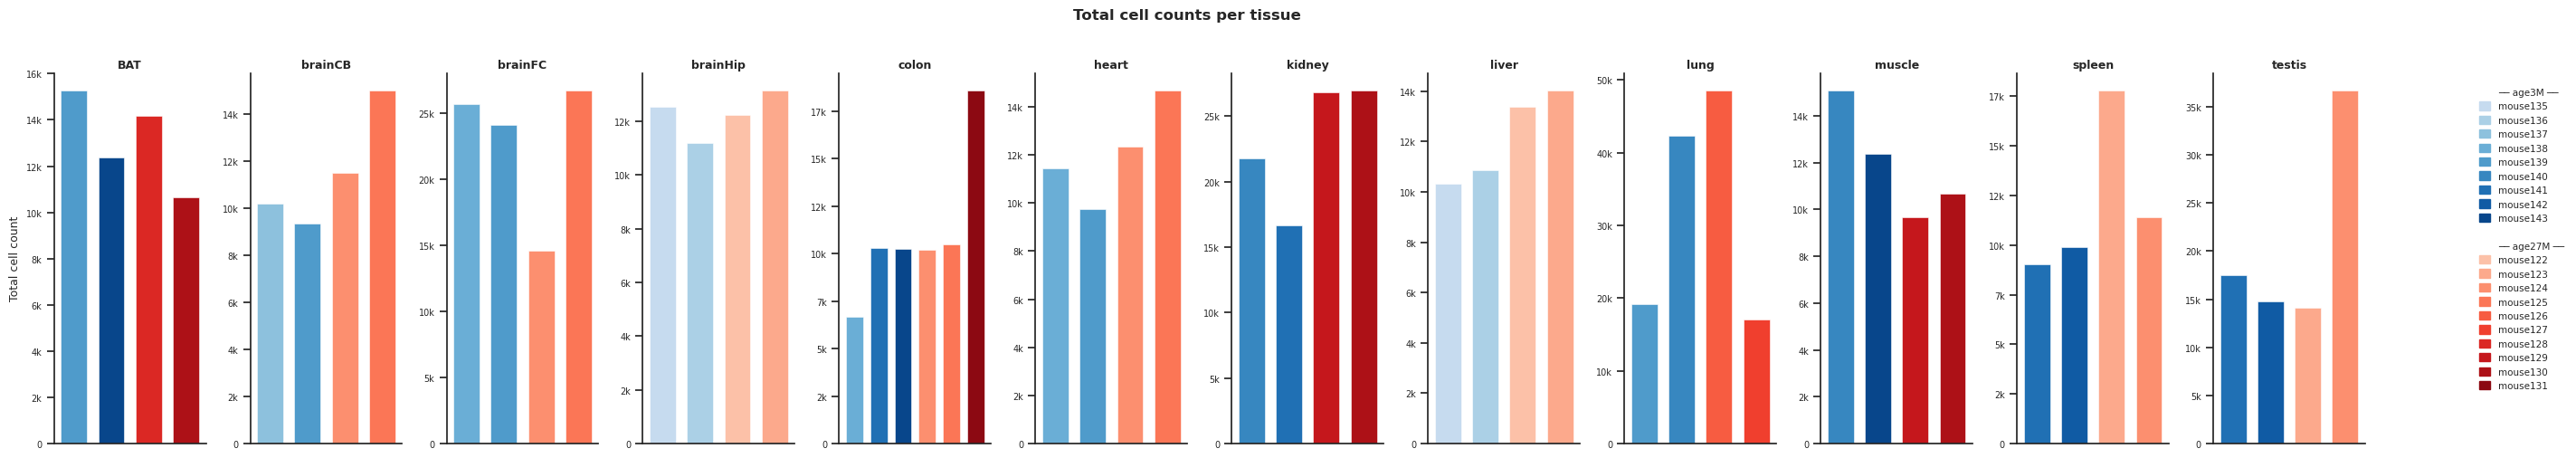

Saved.


In [28]:
# Tissue order (alphabetical, or customize)
tissue_order = sorted(total_counts["tissue"].unique())

# === Plot ===
sns.set_theme(style="ticks", font_scale=1.0)

n_tissues = len(tissue_order)
fig, axes = plt.subplots(
    1, n_tissues,
    figsize=(2.2 * n_tissues, 5),
    sharey=False
)

for ax, tissue in zip(axes, tissue_order):
    sub = total_counts[total_counts["tissue"] == tissue].copy()
    # Keep ordered_mice order, only those present
    sub_mice = [m for m in ordered_mice if m in sub["mouse"].values]
    sub = sub.set_index("mouse").reindex(sub_mice).reset_index()

    colors = [mouse_colors[m] for m in sub["mouse"]]
    bars = ax.bar(range(len(sub)), sub["cell_count"], color=colors, width=0.7, edgecolor="white", linewidth=0.4)

    ax.set_title(tissue, fontsize=9, fontweight="bold", pad=4)
    ax.set_xticks([])
    ax.set_xlabel("")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x/1000)}k" if x >= 1000 else str(int(x))))
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(axis="y", labelsize=7)

axes[0].set_ylabel("Total cell count", fontsize=9)

# === Legend ===
legend_handles = []
# 3M group label
legend_handles.append(mpatches.Patch(color="none", label="── age3M ──"))
for m in mice_3M:
    legend_handles.append(mpatches.Patch(color=mouse_colors[m], label=m))
legend_handles.append(mpatches.Patch(color="none", label=""))
legend_handles.append(mpatches.Patch(color="none", label="── age27M ──"))
for m in mice_27M:
    legend_handles.append(mpatches.Patch(color=mouse_colors[m], label=m))

fig.legend(
    handles=legend_handles,
    loc="center right",
    bbox_to_anchor=(1.08, 0.5),
    fontsize=7.5,
    frameon=False,
    handlelength=1.2,
    handleheight=1.0,
)

fig.suptitle("Total cell counts per tissue", fontsize=12, fontweight="bold", y=1.01)
plt.tight_layout()


plt.savefig("data/cell_counts_qc_per_tissue.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved.")